# K-Fold Cross-Validation Analysis

This notebook summarizes the 5-fold results for catheter image classification.

Evaluation sets:

- Original Test: held-out test fold from models trained on `original`
- HoleAlign Test: held-out test fold from models trained on `original_holealign`
- Original RR: `original_rr` inference using original-trained fold models
- RR + HoleAlign: `original_rr_holealign` inference using holealign-trained fold models

Main comparison excludes Inception-V3 because its Original RR result shows severe architecture-specific instability. Inception-V3 is still loaded in the supplementary tables.

In [13]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score

PROJECT_ROOT = Path('/home/hjj747/catheter-preprocessing')
KFOLD_ROOT = PROJECT_ROOT / 'experiments' / 'kfold'
OUTPUT_DIR = PROJECT_ROOT / 'notebooks' / 'kfold_analysis_outputs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CLASS_NAMES = ['pro1', 'pro2', 'pro3']
SCENARIOS = ['Original Test', 'HoleAlign Test', 'Original RR', 'RR + HoleAlign']

MODELS = [
    {'model': 'ResNet-18', 'slug': 'resnet18', 'input_size': '224 x 224', 'main': True},
    {'model': 'ResNet-50', 'slug': 'resnet50', 'input_size': '224 x 224', 'main': True},
    {'model': 'DenseNet-121', 'slug': 'densenet121', 'input_size': '224 x 224', 'main': True},
    {'model': 'DenseNet-201', 'slug': 'densenet201', 'input_size': '224 x 224', 'main': True},
    {'model': 'EfficientNet-B0', 'slug': 'efficientnetb0', 'input_size': '224 x 224', 'main': True},
    {'model': 'MobileNet-V2', 'slug': 'mobilenetv2', 'input_size': '224 x 224', 'main': True},
    {'model': 'Inception-V3', 'slug': 'inceptionv3', 'input_size': '299 x 299', 'main': False},
]

models_df = pd.DataFrame(MODELS)
models_df

,model,slug,input_size,main
0,ResNet-18,resnet18,224 x 224,True
1,ResNet-50,resnet50,224 x 224,True
2,DenseNet-121,densenet121,224 x 224,True
3,DenseNet-201,densenet201,224 x 224,True
4,EfficientNet-B0,efficientnetb0,224 x 224,True
5,MobileNet-V2,mobilenetv2,224 x 224,True
6,Inception-V3,inceptionv3,299 x 299,False


## Helper Functions

In [14]:
CLASS_DIR_TO_LABEL = {
    'pro_1': 'pro1',
    'pro_2': 'pro2',
    'pro_3': 'pro3',
    'pro1_holealign': 'pro1',
    'pro2_holealign': 'pro2',
    'pro3_holealign': 'pro3',
}


def label_from_path(path_text: str) -> str | None:
    for part in reversed(Path(path_text).parts):
        if part in CLASS_DIR_TO_LABEL:
            return CLASS_DIR_TO_LABEL[part]
    return None


def run_root(slug: str, dataset_kind: str) -> Path:
    return KFOLD_ROOT / f'{slug}_{dataset_kind}_5fold_freeze'


def metric_row(labels, predictions) -> dict:
    return {
        'n': len(labels),
        'accuracy': accuracy_score(labels, predictions),
        'macro_precision': precision_score(labels, predictions, labels=CLASS_NAMES, average='macro', zero_division=0),
        'macro_recall': recall_score(labels, predictions, labels=CLASS_NAMES, average='macro', zero_division=0),
        'macro_f1': f1_score(labels, predictions, labels=CLASS_NAMES, average='macro', zero_division=0),
    }


def load_cv_fold_predictions(root: Path) -> pd.DataFrame:
    frames = []
    for fold_dir in sorted(root.glob('fold_*')):
        csv_path = fold_dir / 'test_predictions.csv'
        if not csv_path.exists():
            continue
        df = pd.read_csv(csv_path)
        df['fold'] = fold_dir.name
        frames.append(df)
    if not frames:
        raise FileNotFoundError(f'No test_predictions.csv found under {root}')
    return pd.concat(frames, ignore_index=True)


def load_inference_fold_predictions(root: Path, prediction_name: str) -> pd.DataFrame:
    frames = []
    for fold_dir in sorted(root.glob('fold_*')):
        csv_path = fold_dir / prediction_name
        if not csv_path.exists():
            continue
        df = pd.read_csv(csv_path)
        df['label'] = df['path'].map(label_from_path)
        if df['label'].isna().any():
            missing = int(df['label'].isna().sum())
            raise ValueError(f'Could not infer labels for {missing} rows in {csv_path}')
        df['correct'] = (df['label'] == df['prediction']).astype(int)
        df['fold'] = fold_dir.name
        frames.append(df)
    if not frames:
        raise FileNotFoundError(f'No {prediction_name} found under {root}')
    return pd.concat(frames, ignore_index=True)


def summarize_by_fold(df: pd.DataFrame, model: str, slug: str, scenario: str, input_size: str, main: bool) -> pd.DataFrame:
    rows = []
    for fold, fold_df in df.groupby('fold', sort=True):
        row = metric_row(fold_df['label'], fold_df['prediction'])
        row.update({'model': model, 'slug': slug, 'scenario': scenario, 'input_size': input_size, 'main': main, 'fold': fold})
        rows.append(row)
    return pd.DataFrame(rows)


def summarize_fold_metrics(fold_df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    group_cols = ['model', 'slug', 'scenario', 'input_size', 'main']
    for keys, group in fold_df.groupby(group_cols, sort=False):
        model, slug, scenario, input_size, main = keys
        rows.append({
            'model': model,
            'slug': slug,
            'scenario': scenario,
            'input_size': input_size,
            'main': bool(main),
            'n_folds': len(group),
            'n_per_fold': int(round(group['n'].mean())),
            'accuracy_mean': group['accuracy'].mean(),
            'accuracy_std': group['accuracy'].std(ddof=1),
            'macro_f1_mean': group['macro_f1'].mean(),
            'macro_f1_std': group['macro_f1'].std(ddof=1),
            'macro_precision_mean': group['macro_precision'].mean(),
            'macro_precision_std': group['macro_precision'].std(ddof=1),
            'macro_recall_mean': group['macro_recall'].mean(),
            'macro_recall_std': group['macro_recall'].std(ddof=1),
        })
    return pd.DataFrame(rows)


def pct_pm(mean: float, std: float) -> str:
    return f'{mean * 100:.2f} +/- {std * 100:.2f}'

## Load K-Fold Results

In [15]:
prediction_frames = {}
fold_metric_frames = []

for item in MODELS:
    model = item['model']
    slug = item['slug']
    input_size = item['input_size']
    main = item['main']

    scenario_specs = [
        ('Original Test', run_root(slug, 'original'), 'cv', None),
        ('HoleAlign Test', run_root(slug, 'original_holealign'), 'cv', None),
        ('Original RR', run_root(slug, 'original'), 'inference', 'original_rr_predictions.csv'),
        ('RR + HoleAlign', run_root(slug, 'original_holealign'), 'inference', 'original_rr_holealign_predictions.csv'),
    ]
    for scenario, root, kind, prediction_name in scenario_specs:
        if kind == 'cv':
            df = load_cv_fold_predictions(root)
        else:
            df = load_inference_fold_predictions(root, prediction_name)
        df['model'] = model
        df['slug'] = slug
        df['scenario'] = scenario
        prediction_frames[(model, scenario)] = df
        fold_metric_frames.append(summarize_by_fold(df, model, slug, scenario, input_size, main))

fold_metrics = pd.concat(fold_metric_frames, ignore_index=True)
summary_metrics = summarize_fold_metrics(fold_metrics)

fold_metrics.to_csv(OUTPUT_DIR / 'kfold_fold_metrics.csv', index=False)
summary_metrics.to_csv(OUTPUT_DIR / 'kfold_summary_metrics.csv', index=False)

summary_metrics.sort_values(['main', 'model', 'scenario'], ascending=[False, True, True]).head(20)

,model,slug,scenario,input_size,main,n_folds,n_per_fold,accuracy_mean,accuracy_std,macro_f1_mean,macro_f1_std,macro_precision_mean,macro_precision_std,macro_recall_mean,macro_recall_std
9,DenseNet-121,densenet121,HoleAlign Test,224 x 224,True,5,36,0.972222,0.027778,0.972125,0.027887,0.974664,0.025343,0.972222,0.027778
10,DenseNet-121,densenet121,Original RR,224 x 224,True,5,180,0.820000,0.050400,0.814007,0.053867,0.831198,0.050208,0.820000,0.050400
8,DenseNet-121,densenet121,Original Test,224 x 224,True,5,36,0.972222,0.048113,0.971578,0.049488,0.978205,0.036148,0.972222,0.048113
11,DenseNet-121,densenet121,RR + HoleAlign,224 x 224,True,5,180,0.984444,0.019003,0.984438,0.019011,0.984780,0.018602,0.984444,0.019003
13,DenseNet-201,densenet201,HoleAlign Test,224 x 224,True,5,36,0.994444,0.012423,0.994435,0.012444,0.994872,0.011467,0.994444,0.012423
14,DenseNet-201,densenet201,Original RR,224 x 224,True,5,180,0.848889,0.026469,0.842052,0.028117,0.876898,0.012614,0.848889,0.026469
12,DenseNet-201,densenet201,Original Test,224 x 224,True,5,36,0.977778,0.036218,0.977739,0.036281,0.978555,0.035405,0.977778,0.036218
15,DenseNet-201,densenet201,RR + HoleAlign,224 x 224,True,5,180,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000
17,EfficientNet-B0,efficientnetb0,HoleAlign Test,224 x 224,True,5,36,0.972222,0.019642,0.972116,0.019779,0.975092,0.016866,0.972222,0.019642
18,EfficientNet-B0,efficientnetb0,Original RR,224 x 224,True,5,180,0.937778,0.020184,0.937069,0.020804,0.944416,0.015398,0.937778,0.020184


## Paper-Style Accuracy Table

Values are mean +/- standard deviation over five fold-trained models. For Original RR and RR + HoleAlign, the same 180-image RR set is evaluated with each fold-trained model.

In [16]:
main_summary = summary_metrics[summary_metrics['main']].copy()

table_rows = []
for item in MODELS:
    if not item['main']:
        continue
    row = {'Model': item['model'], 'Input size': item['input_size']}
    model_summary = main_summary[main_summary['model'] == item['model']]
    for scenario in SCENARIOS:
        scenario_row = model_summary[model_summary['scenario'] == scenario].iloc[0]
        row[scenario] = pct_pm(scenario_row['accuracy_mean'], scenario_row['accuracy_std'])
    original_rr = model_summary[model_summary['scenario'] == 'Original RR']['accuracy_mean'].iloc[0]
    rr_holealign = model_summary[model_summary['scenario'] == 'RR + HoleAlign']['accuracy_mean'].iloc[0]
    row['_sort_rr_holealign'] = rr_holealign
    row['RR improvement (pp)'] = (rr_holealign - original_rr) * 100
    table_rows.append(row)

paper_table = pd.DataFrame(table_rows).sort_values('_sort_rr_holealign', ascending=False).drop(columns=['_sort_rr_holealign'])
paper_table['RR improvement (pp)'] = paper_table['RR improvement (pp)'].map(lambda value: f'{value:.2f}')
paper_table.to_csv(OUTPUT_DIR / 'main_paper_accuracy_table.csv', index=False)
paper_table

,Model,Input size,Original Test,HoleAlign Test,Original RR,RR + HoleAlign,RR improvement (pp)
3,DenseNet-201,224 x 224,97.78 +/- 3.62,99.44 +/- 1.24,84.89 +/- 2.65,100.00 +/- 0.00,15.11
5,MobileNet-V2,224 x 224,96.67 +/- 4.56,98.89 +/- 1.52,86.56 +/- 2.56,99.22 +/- 1.22,12.67
4,EfficientNet-B0,224 x 224,99.44 +/- 1.24,97.22 +/- 1.96,93.78 +/- 2.02,98.56 +/- 0.63,4.78
1,ResNet-50,224 x 224,98.89 +/- 1.52,97.22 +/- 6.21,98.67 +/- 0.93,98.56 +/- 2.62,-0.11
2,DenseNet-121,224 x 224,97.22 +/- 4.81,97.22 +/- 2.78,82.00 +/- 5.04,98.44 +/- 1.90,16.44
0,ResNet-18,224 x 224,97.22 +/- 1.96,97.78 +/- 3.04,88.67 +/- 1.55,98.11 +/- 1.60,9.44


## Paper-Ready Macro Metrics Tables

These tables report accuracy, macro precision, macro recall, and macro F1 as mean +/- standard deviation over five folds. The first table includes all four evaluation settings, and the second table focuses on the robustness comparison between Original RR and RR + HoleAlign.

In [17]:
metric_columns = [
    ('Accuracy', 'accuracy_mean', 'accuracy_std'),
    ('Macro Precision', 'macro_precision_mean', 'macro_precision_std'),
    ('Macro Recall', 'macro_recall_mean', 'macro_recall_std'),
    ('Macro F1', 'macro_f1_mean', 'macro_f1_std'),
]

macro_table_rows = []
for item in MODELS:
    if not item['main']:
        continue
    model_summary = main_summary[main_summary['model'] == item['model']]
    for scenario in SCENARIOS:
        scenario_row = model_summary[model_summary['scenario'] == scenario].iloc[0]
        row = {
            'Model': item['model'],
            'Input size': item['input_size'],
            'Evaluation set': scenario,
            'n/fold': int(scenario_row['n_per_fold']),
        }
        for display_name, mean_col, std_col in metric_columns:
            row[display_name] = pct_pm(scenario_row[mean_col], scenario_row[std_col])
        macro_table_rows.append(row)

paper_ready_macro_metrics = pd.DataFrame(macro_table_rows)
paper_ready_macro_metrics.to_csv(OUTPUT_DIR / 'paper_ready_macro_metrics_table.csv', index=False)
paper_ready_macro_metrics

,Model,Input size,Evaluation set,n/fold,Accuracy,Macro Precision,Macro Recall,Macro F1
0,ResNet-18,224 x 224,Original Test,36,97.22 +/- 1.96,97.44 +/- 1.81,97.22 +/- 1.96,97.19 +/- 2.01
1,ResNet-18,224 x 224,HoleAlign Test,36,97.78 +/- 3.04,97.86 +/- 2.93,97.78 +/- 3.04,97.78 +/- 3.05
2,ResNet-18,224 x 224,Original RR,180,88.67 +/- 1.55,89.36 +/- 1.58,88.67 +/- 1.55,88.45 +/- 1.66
3,ResNet-18,224 x 224,RR + HoleAlign,180,98.11 +/- 1.60,98.16 +/- 1.56,98.11 +/- 1.60,98.11 +/- 1.60
4,ResNet-50,224 x 224,Original Test,36,98.89 +/- 1.52,98.97 +/- 1.40,98.89 +/- 1.52,98.89 +/- 1.52
5,ResNet-50,224 x 224,HoleAlign Test,36,97.22 +/- 6.21,98.04 +/- 4.38,97.22 +/- 6.21,97.29 +/- 6.05
6,ResNet-50,224 x 224,Original RR,180,98.67 +/- 0.93,98.73 +/- 0.84,98.67 +/- 0.93,98.67 +/- 0.93
7,ResNet-50,224 x 224,RR + HoleAlign,180,98.56 +/- 2.62,98.70 +/- 2.32,98.56 +/- 2.62,98.57 +/- 2.58
8,DenseNet-121,224 x 224,Original Test,36,97.22 +/- 4.81,97.82 +/- 3.61,97.22 +/- 4.81,97.16 +/- 4.95
9,DenseNet-121,224 x 224,HoleAlign Test,36,97.22 +/- 2.78,97.47 +/- 2.53,97.22 +/- 2.78,97.21 +/- 2.79


In [18]:
rr_macro_table = paper_ready_macro_metrics[
    paper_ready_macro_metrics['Evaluation set'].isin(['Original RR', 'RR + HoleAlign'])
].copy()
rr_macro_table['Evaluation set'] = pd.Categorical(
    rr_macro_table['Evaluation set'],
    categories=['Original RR', 'RR + HoleAlign'],
    ordered=True,
)
rr_macro_table = rr_macro_table.sort_values(['Model', 'Evaluation set']).reset_index(drop=True)
rr_macro_table.to_csv(OUTPUT_DIR / 'paper_ready_rr_macro_metrics_table.csv', index=False)
rr_macro_table

,Model,Input size,Evaluation set,n/fold,Accuracy,Macro Precision,Macro Recall,Macro F1
0,DenseNet-121,224 x 224,Original RR,180,82.00 +/- 5.04,83.12 +/- 5.02,82.00 +/- 5.04,81.40 +/- 5.39
1,DenseNet-121,224 x 224,RR + HoleAlign,180,98.44 +/- 1.90,98.48 +/- 1.86,98.44 +/- 1.90,98.44 +/- 1.90
2,DenseNet-201,224 x 224,Original RR,180,84.89 +/- 2.65,87.69 +/- 1.26,84.89 +/- 2.65,84.21 +/- 2.81
3,DenseNet-201,224 x 224,RR + HoleAlign,180,100.00 +/- 0.00,100.00 +/- 0.00,100.00 +/- 0.00,100.00 +/- 0.00
4,EfficientNet-B0,224 x 224,Original RR,180,93.78 +/- 2.02,94.44 +/- 1.54,93.78 +/- 2.02,93.71 +/- 2.08
5,EfficientNet-B0,224 x 224,RR + HoleAlign,180,98.56 +/- 0.63,98.60 +/- 0.60,98.56 +/- 0.63,98.55 +/- 0.64
6,MobileNet-V2,224 x 224,Original RR,180,86.56 +/- 2.56,89.26 +/- 1.51,86.56 +/- 2.56,86.55 +/- 2.53
7,MobileNet-V2,224 x 224,RR + HoleAlign,180,99.22 +/- 1.22,99.25 +/- 1.17,99.22 +/- 1.22,99.22 +/- 1.23
8,ResNet-18,224 x 224,Original RR,180,88.67 +/- 1.55,89.36 +/- 1.58,88.67 +/- 1.55,88.45 +/- 1.66
9,ResNet-18,224 x 224,RR + HoleAlign,180,98.11 +/- 1.60,98.16 +/- 1.56,98.11 +/- 1.60,98.11 +/- 1.60


## Table 1. 5-Fold CV Performance on Original Test and HoleAlign Test

This table reports the internal held-out fold performance for models trained and tested under the same image condition. Each value is mean +/- standard deviation over five folds.

In [19]:
model_order = [item['model'] for item in MODELS if item['main']]

table1_cv_performance = paper_ready_macro_metrics[
    paper_ready_macro_metrics['Evaluation set'].isin(['Original Test', 'HoleAlign Test'])
].copy()
table1_cv_performance['Model'] = pd.Categorical(table1_cv_performance['Model'], categories=model_order, ordered=True)
table1_cv_performance['Evaluation set'] = pd.Categorical(
    table1_cv_performance['Evaluation set'],
    categories=['Original Test', 'HoleAlign Test'],
    ordered=True,
)
table1_cv_performance = table1_cv_performance.sort_values(['Model', 'Evaluation set']).reset_index(drop=True)
table1_cv_performance['Model'] = table1_cv_performance['Model'].astype(str)
table1_cv_performance.to_csv(OUTPUT_DIR / 'table1_cv_original_holealign_test.csv', index=False)
table1_cv_performance

,Model,Input size,Evaluation set,n/fold,Accuracy,Macro Precision,Macro Recall,Macro F1
0,ResNet-18,224 x 224,Original Test,36,97.22 +/- 1.96,97.44 +/- 1.81,97.22 +/- 1.96,97.19 +/- 2.01
1,ResNet-18,224 x 224,HoleAlign Test,36,97.78 +/- 3.04,97.86 +/- 2.93,97.78 +/- 3.04,97.78 +/- 3.05
2,ResNet-50,224 x 224,Original Test,36,98.89 +/- 1.52,98.97 +/- 1.40,98.89 +/- 1.52,98.89 +/- 1.52
3,ResNet-50,224 x 224,HoleAlign Test,36,97.22 +/- 6.21,98.04 +/- 4.38,97.22 +/- 6.21,97.29 +/- 6.05
4,DenseNet-121,224 x 224,Original Test,36,97.22 +/- 4.81,97.82 +/- 3.61,97.22 +/- 4.81,97.16 +/- 4.95
5,DenseNet-121,224 x 224,HoleAlign Test,36,97.22 +/- 2.78,97.47 +/- 2.53,97.22 +/- 2.78,97.21 +/- 2.79
6,DenseNet-201,224 x 224,Original Test,36,97.78 +/- 3.62,97.86 +/- 3.54,97.78 +/- 3.62,97.77 +/- 3.63
7,DenseNet-201,224 x 224,HoleAlign Test,36,99.44 +/- 1.24,99.49 +/- 1.15,99.44 +/- 1.24,99.44 +/- 1.24
8,EfficientNet-B0,224 x 224,Original Test,36,99.44 +/- 1.24,99.49 +/- 1.15,99.44 +/- 1.24,99.44 +/- 1.24
9,EfficientNet-B0,224 x 224,HoleAlign Test,36,97.22 +/- 1.96,97.51 +/- 1.69,97.22 +/- 1.96,97.21 +/- 1.98


## Table 2. Robustness Evaluation on Original RR and RR + HoleAlign

This table reports robustness on the RR evaluation sets. The same 180-image RR set is evaluated by each fold-trained model, so the reported standard deviation reflects model variation across folds rather than five independent external test sets.

In [20]:
table2_rr_robustness = paper_ready_macro_metrics[
    paper_ready_macro_metrics['Evaluation set'].isin(['Original RR', 'RR + HoleAlign'])
].copy()
table2_rr_robustness['Model'] = pd.Categorical(table2_rr_robustness['Model'], categories=model_order, ordered=True)
table2_rr_robustness['Evaluation set'] = pd.Categorical(
    table2_rr_robustness['Evaluation set'],
    categories=['Original RR', 'RR + HoleAlign'],
    ordered=True,
)
table2_rr_robustness = table2_rr_robustness.sort_values(['Model', 'Evaluation set']).reset_index(drop=True)
table2_rr_robustness['Model'] = table2_rr_robustness['Model'].astype(str)
table2_rr_robustness.to_csv(OUTPUT_DIR / 'table2_rr_robustness_original_vs_holealign.csv', index=False)
table2_rr_robustness

,Model,Input size,Evaluation set,n/fold,Accuracy,Macro Precision,Macro Recall,Macro F1
0,ResNet-18,224 x 224,Original RR,180,88.67 +/- 1.55,89.36 +/- 1.58,88.67 +/- 1.55,88.45 +/- 1.66
1,ResNet-18,224 x 224,RR + HoleAlign,180,98.11 +/- 1.60,98.16 +/- 1.56,98.11 +/- 1.60,98.11 +/- 1.60
2,ResNet-50,224 x 224,Original RR,180,98.67 +/- 0.93,98.73 +/- 0.84,98.67 +/- 0.93,98.67 +/- 0.93
3,ResNet-50,224 x 224,RR + HoleAlign,180,98.56 +/- 2.62,98.70 +/- 2.32,98.56 +/- 2.62,98.57 +/- 2.58
4,DenseNet-121,224 x 224,Original RR,180,82.00 +/- 5.04,83.12 +/- 5.02,82.00 +/- 5.04,81.40 +/- 5.39
5,DenseNet-121,224 x 224,RR + HoleAlign,180,98.44 +/- 1.90,98.48 +/- 1.86,98.44 +/- 1.90,98.44 +/- 1.90
6,DenseNet-201,224 x 224,Original RR,180,84.89 +/- 2.65,87.69 +/- 1.26,84.89 +/- 2.65,84.21 +/- 2.81
7,DenseNet-201,224 x 224,RR + HoleAlign,180,100.00 +/- 0.00,100.00 +/- 0.00,100.00 +/- 0.00,100.00 +/- 0.00
8,EfficientNet-B0,224 x 224,Original RR,180,93.78 +/- 2.02,94.44 +/- 1.54,93.78 +/- 2.02,93.71 +/- 2.08
9,EfficientNet-B0,224 x 224,RR + HoleAlign,180,98.56 +/- 0.63,98.60 +/- 0.60,98.56 +/- 0.63,98.55 +/- 0.64


## Supplementary Table Including Inception-V3

In [21]:
supplementary_rows = []
for item in MODELS:
    row = {'Model': item['model'], 'Input size': item['input_size'], 'Main table': item['main']}
    model_summary = summary_metrics[summary_metrics['model'] == item['model']]
    for scenario in SCENARIOS:
        scenario_row = model_summary[model_summary['scenario'] == scenario].iloc[0]
        row[scenario] = pct_pm(scenario_row['accuracy_mean'], scenario_row['accuracy_std'])
    original_rr = model_summary[model_summary['scenario'] == 'Original RR']['accuracy_mean'].iloc[0]
    rr_holealign = model_summary[model_summary['scenario'] == 'RR + HoleAlign']['accuracy_mean'].iloc[0]
    row['RR improvement (pp)'] = f'{(rr_holealign - original_rr) * 100:.2f}'
    supplementary_rows.append(row)

supplementary_table = pd.DataFrame(supplementary_rows)
supplementary_table.to_csv(OUTPUT_DIR / 'supplementary_accuracy_table_with_inception.csv', index=False)
supplementary_table

,Model,Input size,Main table,Original Test,HoleAlign Test,Original RR,RR + HoleAlign,RR improvement (pp)
0,ResNet-18,224 x 224,True,97.22 +/- 1.96,97.78 +/- 3.04,88.67 +/- 1.55,98.11 +/- 1.60,9.44
1,ResNet-50,224 x 224,True,98.89 +/- 1.52,97.22 +/- 6.21,98.67 +/- 0.93,98.56 +/- 2.62,-0.11
2,DenseNet-121,224 x 224,True,97.22 +/- 4.81,97.22 +/- 2.78,82.00 +/- 5.04,98.44 +/- 1.90,16.44
3,DenseNet-201,224 x 224,True,97.78 +/- 3.62,99.44 +/- 1.24,84.89 +/- 2.65,100.00 +/- 0.00,15.11
4,EfficientNet-B0,224 x 224,True,99.44 +/- 1.24,97.22 +/- 1.96,93.78 +/- 2.02,98.56 +/- 0.63,4.78
5,MobileNet-V2,224 x 224,True,96.67 +/- 4.56,98.89 +/- 1.52,86.56 +/- 2.56,99.22 +/- 1.22,12.67
6,Inception-V3,299 x 299,False,98.89 +/- 1.52,98.33 +/- 1.52,51.22 +/- 2.06,100.00 +/- 0.00,48.78


## Accuracy Heatmap

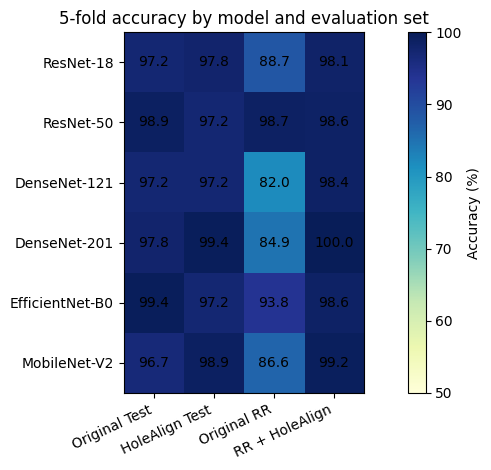

In [22]:
heatmap_df = main_summary.pivot(index='model', columns='scenario', values='accuracy_mean').loc[
    [item['model'] for item in MODELS if item['main']], SCENARIOS
] * 100

fig, ax = plt.subplots(figsize=(9, 4.8))
image = ax.imshow(heatmap_df.values, cmap='YlGnBu', vmin=50, vmax=100)
ax.set_xticks(np.arange(len(heatmap_df.columns)), labels=heatmap_df.columns, rotation=25, ha='right')
ax.set_yticks(np.arange(len(heatmap_df.index)), labels=heatmap_df.index)
ax.set_title('5-fold accuracy by model and evaluation set')
for row_idx in range(heatmap_df.shape[0]):
    for col_idx in range(heatmap_df.shape[1]):
        value = heatmap_df.iloc[row_idx, col_idx]
        ax.text(col_idx, row_idx, f'{value:.1f}', ha='center', va='center', color='black')
fig.colorbar(image, ax=ax, label='Accuracy (%)')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'main_accuracy_heatmap.png', dpi=200)
plt.show()

## RR Improvement After HoleAlign

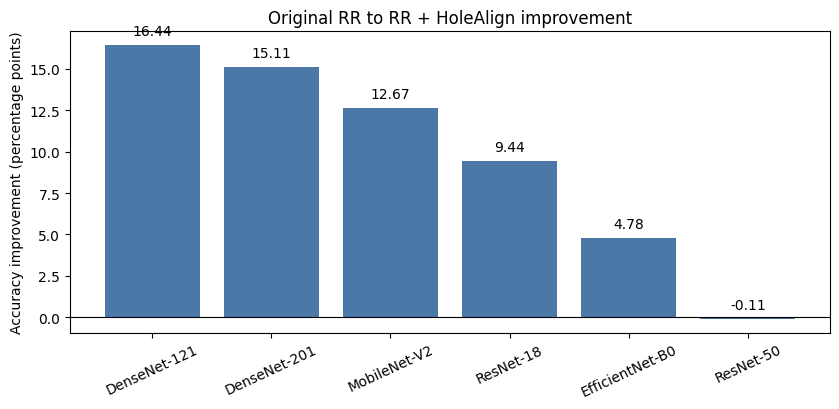

scenario,Original RR,RR + HoleAlign,Improvement_pp
model,,,
DenseNet-121,0.820000,0.984444,16.444444
DenseNet-201,0.848889,1.000000,15.111111
MobileNet-V2,0.865556,0.992222,12.666667
ResNet-18,0.886667,0.981111,9.444444
EfficientNet-B0,0.937778,0.985556,4.777778
ResNet-50,0.986667,0.985556,-0.111111


In [23]:
rr_pivot = main_summary[main_summary['scenario'].isin(['Original RR', 'RR + HoleAlign'])].pivot(
    index='model', columns='scenario', values='accuracy_mean'
).loc[[item['model'] for item in MODELS if item['main']]]
rr_pivot['Improvement_pp'] = (rr_pivot['RR + HoleAlign'] - rr_pivot['Original RR']) * 100
rr_pivot = rr_pivot.sort_values('Improvement_pp', ascending=False)
rr_pivot.to_csv(OUTPUT_DIR / 'rr_holealign_improvement.csv')

fig, ax = plt.subplots(figsize=(8.5, 4.2))
ax.bar(rr_pivot.index, rr_pivot['Improvement_pp'], color='#4C78A8')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Accuracy improvement (percentage points)')
ax.set_title('Original RR to RR + HoleAlign improvement')
ax.tick_params(axis='x', rotation=25)
for idx, value in enumerate(rr_pivot['Improvement_pp']):
    ax.text(idx, value + 0.4, f'{value:.2f}', ha='center', va='bottom')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'rr_holealign_improvement.png', dpi=200)
plt.show()

rr_pivot

## Per-Class Metrics

In [24]:
per_class_rows = []
for (model, scenario), df in prediction_frames.items():
    if model == 'Inception-V3':
        continue
    for class_name in CLASS_NAMES:
        labels_binary = (df['label'] == class_name).astype(int)
        preds_binary = (df['prediction'] == class_name).astype(int)
        per_class_rows.append({
            'model': model,
            'scenario': scenario,
            'class_name': class_name,
            'precision': precision_score(labels_binary, preds_binary, zero_division=0),
            'recall': recall_score(labels_binary, preds_binary, zero_division=0),
            'f1': f1_score(labels_binary, preds_binary, zero_division=0),
            'support': int(labels_binary.sum()),
        })

per_class_metrics = pd.DataFrame(per_class_rows)
per_class_metrics.to_csv(OUTPUT_DIR / 'main_per_class_metrics.csv', index=False)

rr_recall = per_class_metrics[per_class_metrics['scenario'].isin(['Original RR', 'RR + HoleAlign'])].pivot_table(
    index=['model', 'class_name'], columns='scenario', values='recall'
) * 100
rr_recall['Recall improvement (pp)'] = rr_recall['RR + HoleAlign'] - rr_recall['Original RR']
rr_recall.sort_values('Recall improvement (pp)', ascending=False).head(20)

scenario                    Original RR  RR + HoleAlign  \
model           class_name                                
DenseNet-201    pro2          60.333333      100.000000   
DenseNet-121    pro2          63.000000       97.333333   
MobileNet-V2    pro1          73.666667      100.000000   
ResNet-18       pro2          75.333333       98.666667   
EfficientNet-B0 pro2          83.333333      100.000000   
MobileNet-V2    pro3          86.333333       97.666667   
DenseNet-121    pro3          88.333333       98.333333   
                pro1          94.666667       99.666667   
DenseNet-201    pro1          97.000000      100.000000   
                pro3          97.333333      100.000000   
ResNet-18       pro3          96.333333       99.000000   
                pro1          94.333333       96.666667   
EfficientNet-B0 pro3          98.000000      100.000000   
ResNet-50       pro2          96.333333       98.333333   
MobileNet-V2    pro2          99.666667      100.000000   
ResNet-50       pro1         100.000000       99.666667   
                pro3          99.666667       97.666667   
EfficientNet-B0 pro1         100.000000       95.666667   

scenario                    Recall improvement (pp)  
model           class_name                           
DenseNet-201    pro2                      39.666667  
DenseNet-121    pro2                      34.333333  
MobileNet-V2    pro1                      26.333333  
ResNet-18       pro2                      23.333333  
EfficientNet-B0 pro2                      16.666667  
MobileNet-V2    pro3                      11.333333  
DenseNet-121    pro3                      10.000000  
                pro1                       5.000000  
DenseNet-201    pro1                       3.000000  
                pro3                       2.666667  
ResNet-18       pro3                       2.666667  
                pro1                       2.333333  
EfficientNet-B0 pro3                       2.000000  
ResNet-50       pro2                       2.000000  
MobileNet-V2    pro2                       0.333333  
ResNet-50       pro1                      -0.333333  
                pro3                      -2.000000  
EfficientNet-B0 pro1                      -4.333333

## Aggregate Confusion Matrices

The RR confusion matrices aggregate predictions from five fold-trained models. Therefore, each class has support 60 x 5 = 300 for RR evaluations.

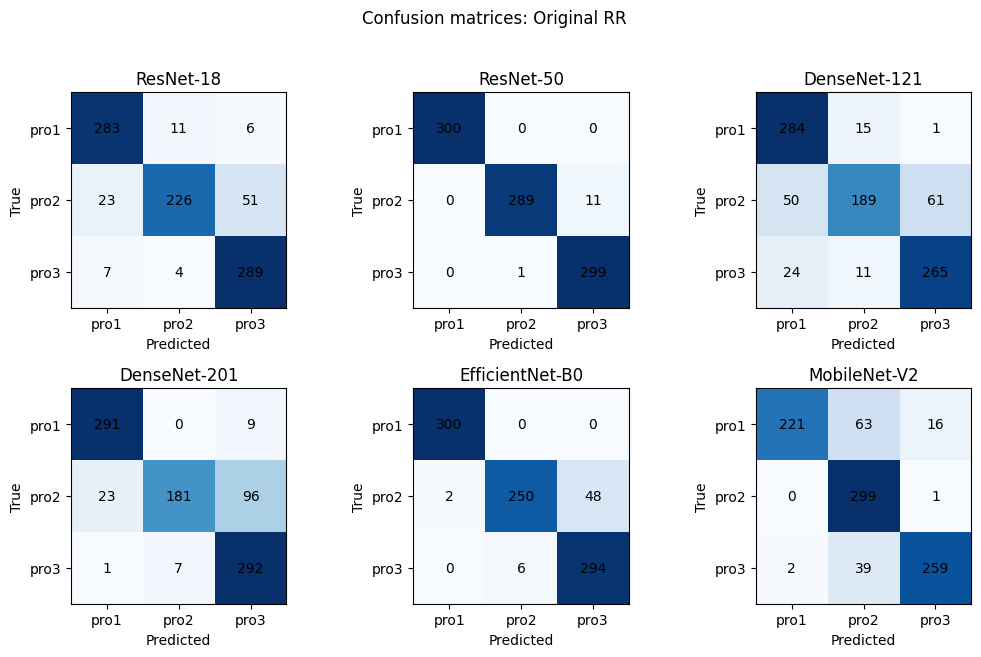

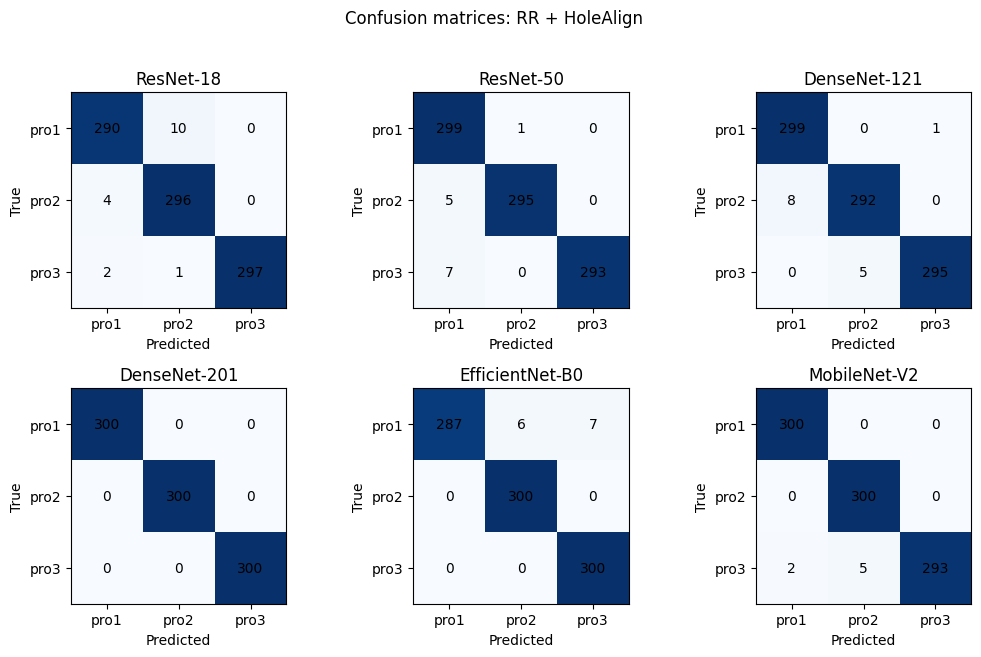

In [25]:
def plot_confusion_grid(scenario: str, output_name: str):
    main_models = [item['model'] for item in MODELS if item['main']]
    n_cols = 3
    n_rows = int(np.ceil(len(main_models) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(10.5, 3.2 * n_rows))
    axes = np.array(axes).reshape(-1)
    for ax, model in zip(axes, main_models):
        df = prediction_frames[(model, scenario)]
        matrix = confusion_matrix(df['label'], df['prediction'], labels=CLASS_NAMES)
        ax.imshow(matrix, cmap='Blues')
        ax.set_title(model)
        ax.set_xticks(range(len(CLASS_NAMES)), labels=CLASS_NAMES)
        ax.set_yticks(range(len(CLASS_NAMES)), labels=CLASS_NAMES)
        ax.set_xlabel('Predicted')
        ax.set_ylabel('True')
        for i in range(matrix.shape[0]):
            for j in range(matrix.shape[1]):
                ax.text(j, i, str(matrix[i, j]), ha='center', va='center', color='black')
    for ax in axes[len(main_models):]:
        ax.axis('off')
    fig.suptitle(f'Confusion matrices: {scenario}', y=1.02)
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / output_name, dpi=200, bbox_inches='tight')
    plt.show()

plot_confusion_grid('Original RR', 'confusion_matrices_original_rr_main.png')
plot_confusion_grid('RR + HoleAlign', 'confusion_matrices_rr_holealign_main.png')

## Repeated Misclassifications

In [26]:
error_rows = []
for (model, scenario), df in prediction_frames.items():
    if model == 'Inception-V3':
        continue
    wrong = df[df['label'] != df['prediction']].copy()
    if wrong.empty:
        continue
    wrong['file'] = wrong['path'].map(lambda value: Path(value).name if 'path' in wrong.columns else '')
    grouped = wrong.groupby(['file', 'label', 'prediction']).agg(
        wrong_folds=('fold', 'nunique'),
        total_errors=('fold', 'size'),
    ).reset_index()
    grouped['model'] = model
    grouped['scenario'] = scenario
    error_rows.append(grouped)

repeated_errors = pd.concat(error_rows, ignore_index=True) if error_rows else pd.DataFrame()
repeated_errors = repeated_errors.sort_values(['wrong_folds', 'total_errors', 'model', 'file'], ascending=[False, False, True, True])
repeated_errors.to_csv(OUTPUT_DIR / 'main_repeated_misclassifications.csv', index=False)
repeated_errors.head(40)

,file,label,prediction,wrong_folds,total_errors,model,scenario
87,2_F_12.png,pro2,pro3,5,5,DenseNet-121,Original RR
90,2_F_21.png,pro2,pro1,5,5,DenseNet-121,Original RR
96,2_F_29.png,pro2,pro1,5,5,DenseNet-121,Original RR
101,2_S_22.png,pro2,pro1,5,5,DenseNet-121,Original RR
109,2_S_31.png,pro2,pro3,5,5,DenseNet-121,Original RR
111,2_S_40.png,pro2,pro3,5,5,DenseNet-121,Original RR
114,2_S_47.png,pro2,pro3,5,5,DenseNet-121,Original RR
115,2_S_71.png,pro2,pro1,5,5,DenseNet-121,Original RR
128,2_s22_5.BMP,pro1,pro2,5,5,DenseNet-121,Original RR
135,3_FS (99).png,pro3,pro2,5,5,DenseNet-121,Original RR


## Key Takeaways

- HoleAlign substantially improves RR robustness for most models.
- ResNet-50 is already robust on Original RR, so its gain after HoleAlign is small.
- DenseNet-121, DenseNet-201, MobileNet-V2, and ResNet-18 show clear recovery after HoleAlign.
- Inception-V3 is excluded from the main comparison because Original RR collapses with a strong pro1 bias, although RR + HoleAlign reaches 100%.
- Because RR and RR + HoleAlign use the same 180-image external evaluation set for each fold-trained model, report these values as model-stability estimates across folds, not as five independent external test sets.